# SDEE

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


### Add Statistical Aggregations of issues

In [2]:
from features_agreggator import aggregate_features


datasets = [
    ("datasets/apache_iteration_0.csv","datasets/apache_issue_0.csv", "datasets/apache_iteration_0_features.csv"),
    ("datasets/apache_iteration_30.csv","datasets/apache_issue_30.csv", "datasets/apache_iteration_30_features.csv"),
    ("datasets/apache_iteration_50.csv","datasets/apache_issue_50.csv", "datasets/apache_iteration_50_features.csv"),
    ("datasets/apache_iteration_80.csv","datasets/apache_issue_80.csv", "datasets/apache_iteration_80_features.csv")
]
for dataset in datasets:
    iterations, issues, output = dataset
    aggregate_features(iterations, issues, output)

Nº Iterations: 348
Nº Issues: 5826
Aggregating features. Progress:[###################################]
Nº Iterations: 348
Nº Issues: 5826
Aggregating features. Progress:[###################################]
Nº Iterations: 348
Nº Issues: 5826
Aggregating features. Progress:[###################################]
Nº Iterations: 348
Nº Issues: 5826
Aggregating features. Progress:[###################################]


In [3]:
# load dataset heads:
dataset_iteration_0 = pd.read_csv("datasets/apache_iteration_0_features.csv")
dataset_iteration_30 = pd.read_csv("datasets/apache_iteration_30_features.csv")
dataset_iteration_50 = pd.read_csv("datasets/apache_iteration_50_features.csv")
dataset_iteration_80 = pd.read_csv("datasets/apache_iteration_80_features.csv")
dataset_iteration_30.head()

,boardid,sprintid,name,vel_diff,planday,no_issue_starttime,vel_starttime,no_issue_added,vel_added,no_issue_removed,...,type_freq_Story,priority_freq_Trivial,type_freq_Documentation,type_freq_Wish,priority_freq_Blocker,type_freq_Sub-task,type_freq_Technical task,type_freq_New Feature,type_freq_Test,type_freq_Umbrella
0,1,8,Q2'14 Sprint 1,0,9,0,0,2,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,12,Q2'14 Sprint 2,3,13,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,13,Q2 Sprint 3,0,12,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,20,Q2 Sprint 4,-1,12,3,3,1,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,24,Q3 Sprint 1,0,9,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Aggregate Throughput with MCS

In [4]:
from features_agreggator import add_mcs_throughput

dataset_iteration_0_mcs = add_mcs_throughput(dataset_iteration_0)
dataset_iteration_30_mcs = add_mcs_throughput(dataset_iteration_30)
dataset_iteration_50_mcs = add_mcs_throughput(dataset_iteration_50)
dataset_iteration_80_mcs = add_mcs_throughput(dataset_iteration_80)

dataset_iteration_30_mcs.head()

,boardid,sprintid,name,vel_diff,planday,no_issue_starttime,vel_starttime,no_issue_added,vel_added,no_issue_removed,...,type_freq_Wish,priority_freq_Blocker,type_freq_Sub-task,type_freq_Technical task,type_freq_New Feature,type_freq_Test,type_freq_Umbrella,mcs_throughput_50,mcs_throughput_85,mcs_throughput_95
0,1,8,Q2'14 Sprint 1,0,9,0,0,2,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,12,Q2'14 Sprint 2,3,13,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,13,Q2 Sprint 3,0,12,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,20,Q2 Sprint 4,-1,12,3,3,1,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,24,Q3 Sprint 1,0,9,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Train dataset 30%

GradientBoostingRegressor nmae: 0.18187281009077397
RandomForestRegressor nmae: 0.24691432502037974
avg nmae: 0.21439356755557687
[0.18187281009077397, 0.24691432502037974]


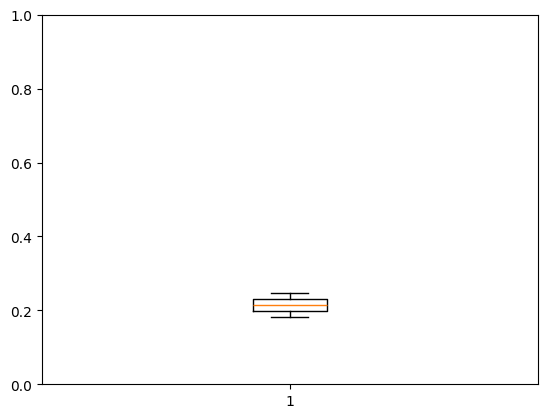

In [5]:
# filter out columns that are not features
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from custom_kfold import CustomKFold
from montecarlo_simulation import MCSimulation
from train_dataset import get_X_y, train_best, train_model_cv

X, y = get_X_y(dataset_iteration_30)

n_folds = 10
kf = CustomKFold(n_splits=n_folds, shuffle=False)
# tkf = TimeSeriesSplit(n_splits=3)

nmae_values_30 = []
models = [
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
    RandomForestRegressor(n_estimators=500, max_depth=7),
    #MCSimulation(percentile=95, simulations=1),
]

for model in models:
    nmae = train_model_cv(X, y, model, kf)
    print(f"{model.__class__.__name__} nmae: {nmae}")
    nmae_values_30.append(nmae)

print(f"avg nmae: {sum(nmae_values_30) / len(nmae_values_30)}")
print(nmae_values_30)

### Test dataset 30% with MCS throughput

GradientBoostingRegressor nmae: 0.19127695874301648
RandomForestRegressor nmae: 0.2526841417511384
avg nmae: 0.22198055024707744
[0.19127695874301648, 0.2526841417511384]


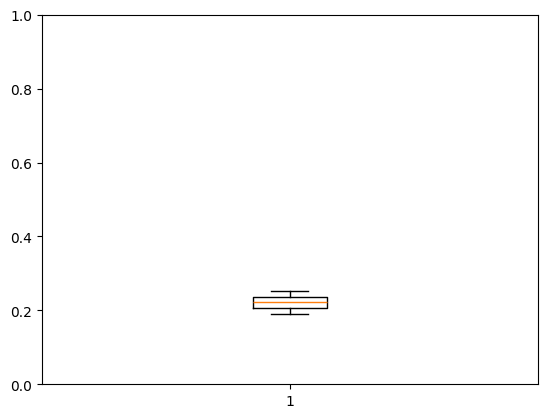

In [6]:
X, y = get_X_y(dataset_iteration_30_mcs)

nmae_values_30_mcs = []

for model in models:
    nmae = train_model_cv(X, y, model, kf)
    print(f"{model.__class__.__name__} nmae: {nmae}")
    nmae_values_30_mcs.append(nmae)

print(f"avg nmae: {sum(nmae_values_30_mcs) / len(nmae_values_30_mcs)}")
print(nmae_values_30_mcs)

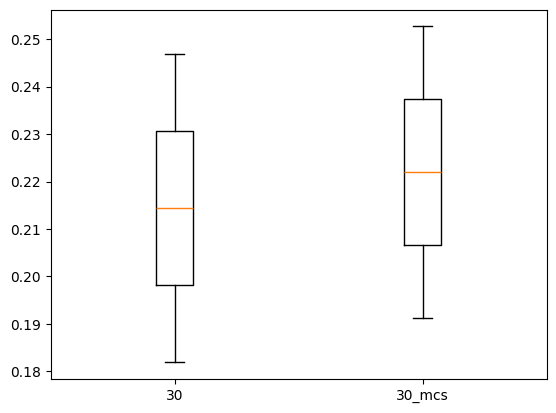

In [8]:
plt.boxplot([nmae_values_30, nmae_values_30_mcs], labels=["30", "30_mcs"])
plt.show()